In [13]:
pip install tensorflow-directml

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow-directml (from versions: none)
ERROR: No matching distribution found for tensorflow-directml


In [14]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [15]:
train_dir = "dataset_final/train"
val_dir = "dataset_final/val"
test_dir = "dataset_final/test"

In [16]:
train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [17]:
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

Found 2278 images belonging to 2 classes.
Found 494 images belonging to 2 classes.
Found 484 images belonging to 2 classes.


In [18]:
model = tf.keras.models.Sequential([
    
    tf.keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation="relu"),

    tf.keras.layers.Dense(1,activation="sigmoid")
])

In [19]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.8455 - loss: 0.4645 - val_accuracy: 0.8340 - val_loss: 0.4076
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.8529 - loss: 0.3409 - val_accuracy: 0.8158 - val_loss: 0.3911
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9091 - loss: 0.2218 - val_accuracy: 0.8846 - val_loss: 0.2440
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 65s 895ms/step - accuracy: 0.9688 - loss: 0.0886 - val_accuracy: 0.9231 - val_loss: 0.2122
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 65s 904ms/step - accuracy: 0.9895 - loss: 0.0319 - val_accuracy: 0.9231 - val_loss: 0.2457
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 67s 933ms/step - accuracy: 0.9917 - loss: 0.0244 - val_accuracy: 0.9109 - val_loss: 0.3662
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 64s 888ms/step - accuracy: 0.9991 - loss: 0.0037 - val_accuracy: 0.9291 - val_loss: 0.2778
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 63s 881ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9

In [21]:
test_loss , test_acc = model.evaluate(test_data)

print("Test Accuracy:",test_acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 349ms/step - accuracy: 0.9174 - loss: 0.4011
Test Accuracy: 0.9173553586006165


In [22]:
model.save("leukemia_model.h5")

In [31]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "dataset_final/test/leukemia/WBC-Malignant-Early-039.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

confidence = prediction[0][0]

if confidence > 0.5:
    print("Prediction: Leukemia")
    print("Confidence:", confidence)
else:
    print("Prediction: Healthy")
    print("Confidence:", 1-confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Prediction: Leukemia
Confidence: 1.0


Prediction: Leukemia


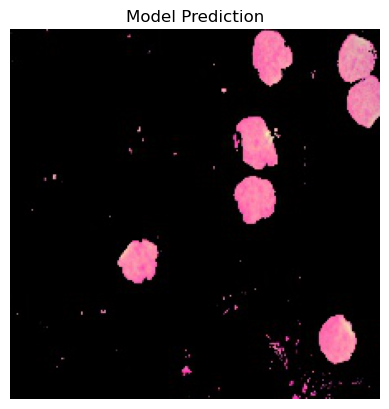

In [32]:
if prediction[0][0] > 0.5:
    print("Prediction: Leukemia")
else:
    print("Prediction: Healthy")
    
plt.imshow(img)
plt.title("Model Prediction")
plt.axis("off")
plt.show()
    

In [33]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "dataset_final/test/healthy/WBC-Benign-031.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

confidence = prediction[0][0]

if confidence > 0.5:
    print("Prediction: Leukemia")
    print("Confidence:", confidence)
else:
    print("Prediction: Healthy")
    print("Confidence:", 1-confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Prediction: Healthy
Confidence: 0.97484875


Prediction: Healthy


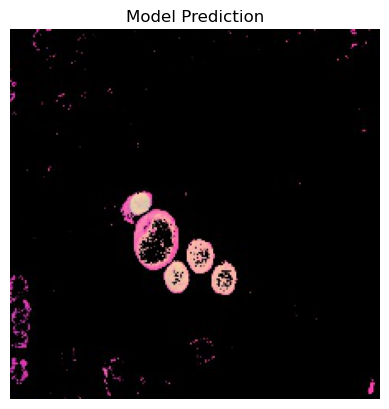

In [34]:
if prediction[0][0] > 0.5:
    print("Prediction: Leukemia")
else:
    print("Prediction: Healthy")
    
plt.imshow(img)
plt.title("Model Prediction")
plt.axis("off")
plt.show()